In [ ]:
pip install numpy opencv-python scikit-learn matplotlib seaborn

In [ ]:
pip install tensorflow

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


Loading Images...
Dataset Loaded Successfully
Images Shape : (20000, 64, 64, 1)


c:\Users\PURUSHOTHAMAN S\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8789 - loss: 0.3668 - val_accuracy: 0.9956 - val_loss: 0.0186
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9933 - loss: 0.0233 - val_accuracy: 0.9984 - val_loss: 0.0057
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9987 - val_loss: 0.0111
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9965 - loss: 0.0110 - val_accuracy: 0.9994 - val_loss: 0.0039
Epoch 5/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9973 - loss: 0.0089 - val_accuracy: 0.9994 - val_loss: 0.0044
Epoch 6/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9955 - loss: 0.0134 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 7/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9985 - loss: 0.0053 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 8/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9973 - loss: 0.0081 - val_accu

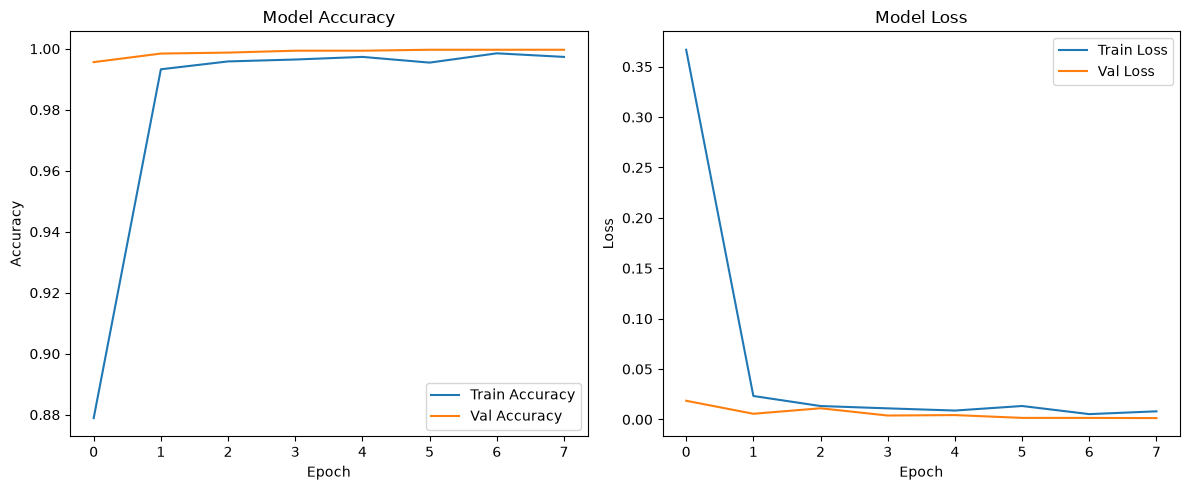

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


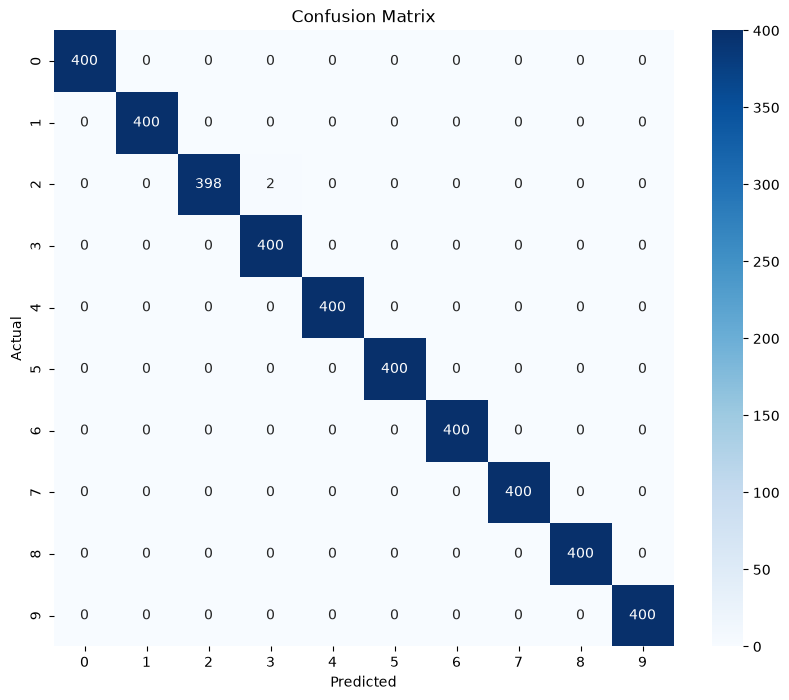

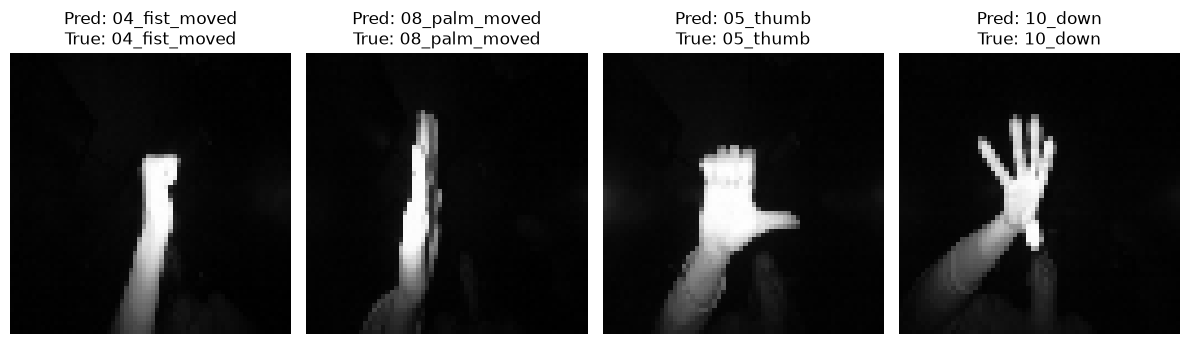

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ==================================================
# DATASET PATH
# ==================================================

DATASET_PATH = "leapGestRecog"

# ==================================================
# LOAD DATASET
# ==================================================

images = []
labels = []

print("Loading Images...")

for subject in os.listdir(DATASET_PATH):

    subject_path = os.path.join(DATASET_PATH, subject)

    if not os.path.isdir(subject_path):
        continue

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(subject_path, gesture)

        if not os.path.isdir(gesture_path):
            continue

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(
                gesture_path,
                img_name
            )

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            img = cv2.resize(img, (64, 64))

            img = img / 255.0

            images.append(img)

            labels.append(gesture)

print("Dataset Loaded Successfully")

# ==================================================
# CONVERT TO NUMPY
# ==================================================

X = np.array(images)
X = X.reshape(-1, 64, 64, 1)

y = np.array(labels)

print("Images Shape :", X.shape)

# ==================================================
# LABEL ENCODING
# ==================================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

class_names = encoder.classes_

y_categorical = to_categorical(y_encoded)

# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

# ==================================================
# CNN MODEL
# ==================================================

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(len(class_names), activation='softmax'))

# ==================================================
# COMPILE MODEL
# ==================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==================================================
# TRAIN MODEL
# ==================================================

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==================================================
# EVALUATION
# ==================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"\nTest Accuracy : {accuracy*100:.2f}%")

# ==================================================
# ACCURACY GRAPH
# ==================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Val Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# ==================================================
# LOSS GRAPH
# ==================================================

plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Val Loss'
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

# ==================================================
# CONFUSION MATRIX
# ==================================================

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==================================================
# 4 SAMPLE PREDICTIONS
# ==================================================

plt.figure(figsize=(12,4))

for i in range(4):

    plt.subplot(1,4,i+1)

    img = X_test[i]

    prediction = model.predict(
        img.reshape(1,64,64,1),
        verbose=0
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    true_class = class_names[
        np.argmax(y_test[i])
    ]

    plt.imshow(
        img.squeeze(),
        cmap='gray'
    )

    plt.title(
        f"Pred: {predicted_class}\nTrue: {true_class}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()